# Train the latent draft model on extracted traces

Data comes from `fastdocling-extract` (`data/traces/*.safetensors`): per page, the target model's
hidden states at every position plus the tokens it generated. `fastdocling.data` streams these
from disk one page at a time and cuts the DocTags region into fixed-length windows, so the whole
corpus (tens of GB) never has to fit in memory.

**Alignment.** Hidden state `i` is the target's state after reading token `i`; the target's LM head
turned it into token `i+1`. In speculative decoding that token is already known when the draft
runs (it is the "bonus" token of the verification step), so the draft heads predict the tokens
*after* it: head `j` predicts offset `j+1` from the state it reads. Training targets follow the
same convention (`fastdocling.data.FIRST_OFFSET = 2`), so the teacher-forced acceptance metric
and the live speculative loop measure the same thing.

**Inputs.** `FEATURES="last"` feeds the final normed state (576-d). `FEATURES="eagle3"` feeds the
concatenation of layers 2/14/27 (1728-d), the EAGLE-3 recipe; the draft then learns an input
projection back to 576.

In [1]:
from pathlib import Path
from time import perf_counter

import mlx.core as mx
import numpy as np
import torch
from cut_cross_entropy import linear_cross_entropy
from mlx_vlm import load
from torch import nn
from torch.nn import functional as F
from tqdm.auto import tqdm

from fastdocling.data import FIRST_OFFSET, HIDDEN_SIZE, input_dim, iterate_batches, plan, scan_traces, split

VOCAB_SIZE = 100_352
TRACES = Path("data/traces")

# --- training configuration -------------------------------------------------------------
CONTEXT_LENGTH = 64   # window the draft attends over
HORIZON = 2            # future tokens predicted per position (NUM_PREDICTIONS)
BATCH_SIZE = 16
EPOCHS = 3             # see the epoch table below
FEATURES = "last"      # or "eagle3"
MUON_LR = 0.02         # Muon: 2-D weight matrices inside the block and heads
ADAMW_LR = 3e-4        # AdamW: embeddings, norms, biases
WARMUP_STEPS = 10
EVAL_EVERY = 50        # steps between acceptance-rate evaluations on the holdout set
EVAL_BATCHES = 8       # holdout batches used for the running acceptance metric
OUTPUT = Path("checkpoints/latent_draft.pt")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [2]:
infos = scan_traces(TRACES, min_completion=CONTEXT_LENGTH + HORIZON + FIRST_OFFSET - 1)  # one full training window
train_infos, holdout_infos = split(infos, holdout_fraction=0.02)
schedule = plan(train_infos, CONTEXT_LENGTH, BATCH_SIZE, HORIZON)
TOTAL_STEPS = schedule.steps_for_epochs(EPOCHS)
print(schedule.describe(steps=TOTAL_STEPS))
print(f"holdout: {len(holdout_infos)} pages")

941 pages, 975,303 usable DocTags positions
context=64 horizon=2 batch=16 -> 1,024 tokens/step
14,098 windows/epoch -> 881 steps/epoch
2,643 steps = 3.00 epochs
holdout: 19 pages


## How many epochs?

An **epoch** is one pass over every non-overlapping window the corpus yields:

```
tokens_per_step   = CONTEXT_LENGTH * BATCH_SIZE
windows_per_epoch = sum over pages of  floor(completion_tokens / (CONTEXT_LENGTH + HORIZON + 1))
steps_per_epoch   = windows_per_epoch // BATCH_SIZE
epochs            = steps / steps_per_epoch
```

Pages average ~1,000 generated DocTags tokens, so long contexts waste data: a page shorter than
`CONTEXT_LENGTH + HORIZON` yields no window at all, and the remainder of every page is dropped.
Measured on an earlier, larger corpus (958 training pages, ~980k usable positions, 4.6M-parameter draft); the current run uses context 128, batch 8 on the pages listed above, so re-read the printed plan rather than this table:

| context | batch | tokens/step | windows/epoch | steps/epoch | data kept |
|--------:|------:|------------:|--------------:|------------:|----------:|
| 256     | 16    | 4,096       | 3,298         | 206         | 87%       |
| 512     | 8     | 4,096       | 1,430         | 178         | 75%       |
| 1024    | 4     | 4,096       | 483           | 120         | 51%       |

The full corpus (5,379 pages) is ~5.5M positions: about **1,150 steps/epoch** at context 256,
batch 16. Successive epochs cut windows at different random offsets, so repeated passes are not
exact duplicates.

**Recommendation.** For a draft of a few million parameters, 2-4 epochs on 5.5M tokens is the right range:
one epoch underfits (the draft needs to see each DocTags pattern several times), and beyond four
the holdout token accuracy stops improving while training loss keeps falling. Start with
`EPOCHS = 3` (~3,500 steps at 4,096 tokens/step, ~14M tokens seen) and watch the holdout
accuracy printed after each epoch. Keep `CONTEXT_LENGTH` at 256 or 512 unless windows are packed
across pages.

In [3]:
class LatentDraft(nn.Module):
    """One causal Transformer block with parallel future-token heads."""

    def __init__(self, context_length: int, in_dim: int = HIDDEN_SIZE, horizon: int = HORIZON) -> None:
        super().__init__()
        self.horizon = horizon
        self.proj = nn.Identity() if in_dim == HIDDEN_SIZE else nn.Linear(in_dim, HIDDEN_SIZE)
        self.positions = nn.Embedding(context_length, HIDDEN_SIZE)
        block = nn.TransformerEncoderLayer(
            d_model=HIDDEN_SIZE, nhead=9, dim_feedforward=1536, dropout=0.0,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(block, num_layers=1, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(HIDDEN_SIZE)
        self.future_heads = nn.Linear(HIDDEN_SIZE, horizon * HIDDEN_SIZE)

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        T = hidden_states.shape[1]
        x = self.proj(hidden_states) + self.positions(torch.arange(T, device=hidden_states.device))
        causal_mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        x = self.norm(self.transformer(x, mask=causal_mask, is_causal=True))
        return self.future_heads(x).unflatten(-1, (self.horizon, HIDDEN_SIZE))


# Reuse Granite's frozen vocabulary projection, so 576-wide outputs become token logits.
target_model, target_processor = load("ibm-granite/granite-docling-258M-mlx")
lm_head = torch.from_numpy(np.asarray(target_model.language_model.lm_head.weight.astype(mx.float32))).to(device)
assert lm_head.shape == (VOCAB_SIZE, HIDDEN_SIZE), lm_head.shape

draft = LatentDraft(CONTEXT_LENGTH, input_dim(FEATURES)).to(device)
# Muon orthogonalizes the momentum of each 2-D weight matrix (Newton-Schulz), which suits the
# transformer block and heads; embeddings, LayerNorm gains and biases stay on AdamW.
muon_params = [p for n, p in draft.named_parameters() if p.ndim == 2 and not n.startswith("positions")]
adamw_params = [p for n, p in draft.named_parameters() if not (p.ndim == 2 and not n.startswith("positions"))]
optimizers = [
    torch.optim.Muon(muon_params, lr=MUON_LR, weight_decay=0.01, momentum=0.95, nesterov=True),
    torch.optim.AdamW(adamw_params, lr=ADAMW_LR, weight_decay=0.01),
]
warmup_cosine = lambda s: min(1.0, (s + 1) / WARMUP_STEPS) * 0.5 * (1 + np.cos(np.pi * min(1.0, s / max(1, TOTAL_STEPS))))
lr_schedules = [torch.optim.lr_scheduler.LambdaLR(o, warmup_cosine) for o in optimizers]
print(f"{sum(p.numel() for p in draft.parameters()):,} draft parameters, input dim {input_dim(FEATURES)}")
print(f"Muon on {sum(p.numel() for p in muon_params):,} params, AdamW on {sum(p.numel() for p in adamw_params):,}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

3,806,016 draft parameters, input dim 576
Muon on 3,760,128 params, AdamW on 45,888


In [4]:
def loss_fn(predicted: torch.Tensor, target_hidden: torch.Tensor, target_tokens: torch.Tensor):
    # Apple CCE avoids materializing the 100k-token logit matrix per head.
    token_loss = sum(
        linear_cross_entropy(predicted[:, :, k].flatten(0, 1), lm_head, target_tokens[:, :, k].flatten(), impl="torch_compile")
        for k in range(HORIZON)
    ) / HORIZON
    hidden_loss = F.mse_loss(predicted, target_hidden)
    return token_loss + 0.1 * hidden_loss, token_loss


# Fixed holdout batches, loaded once, for the running acceptance metric.
eval_batches = []
for batch in iterate_batches(holdout_infos, CONTEXT_LENGTH, BATCH_SIZE, HORIZON, FEATURES, seed=0, device=device):
    eval_batches.append(batch)
    if len(eval_batches) == EVAL_BATCHES:
        break


@torch.inference_mode()
def acceptance(batches=None) -> dict[str, float]:
    """Teacher-forced acceptance on holdout windows.

    accepted/round = expected length of the matching prefix of the HORIZON proposals, i.e.
    sum_k prod_{j<=k} [head_j correct]; tokens/round = 1 + that (the target's bonus token).
    Also reports per-head next-token accuracy.
    """
    draft.eval()
    hits = torch.zeros(HORIZON); prefix = 0.0; count = 0
    for x, th, tt in (batches if batches is not None else eval_batches):
        match = (F.linear(draft(x), lm_head).argmax(-1) == tt).float()   # [B, T, H]
        hits += match.sum(dim=(0, 1)).cpu()
        prefix += match.cumprod(dim=-1).sum().item()
        count += match.shape[0] * match.shape[1]
    draft.train()
    acc = (hits / count).tolist()
    return {"accepted_per_round": prefix / count, "tokens_per_round": 1 + prefix / count,
            **{f"head{k+1}": a for k, a in enumerate(acc)}}


def evaluate() -> dict[str, float]:
    """Full holdout pass (all windows)."""
    return acceptance(iterate_batches(holdout_infos, CONTEXT_LENGTH, BATCH_SIZE, HORIZON, FEATURES, seed=0, device=device, drop_last=False))


history = []   # (step, metrics) logged every EVAL_EVERY steps

step = 0
started = perf_counter()
progress = tqdm(total=TOTAL_STEPS, unit="step", dynamic_ncols=True)
for epoch in range(EPOCHS):
    for x, target_hidden, target_tokens in iterate_batches(
        train_infos, CONTEXT_LENGTH, BATCH_SIZE, HORIZON, FEATURES, seed=epoch, device=device
    ):
        loss, token_loss = loss_fn(draft(x), target_hidden, target_tokens)
        for o in optimizers:
            o.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(draft.parameters(), 1.0)
        for o, sch in zip(optimizers, lr_schedules):
            o.step(); sch.step()
        step += 1
        progress.update()
        if step % EVAL_EVERY == 0 or step == 1:
            m = acceptance()
            history.append((step, {"loss": loss.item(), "token_loss": token_loss.item(), **m}))
        tps = step * schedule.tokens_per_step / (perf_counter() - started)
        progress.set_postfix(epoch=epoch, loss=f"{loss.item():.3f}", acc_round=f"{history[-1][1]['accepted_per_round']:.2f}",
                             h1=f"{history[-1][1]['head1']:.2f}", lr=f"{lr_schedules[0].get_last_lr()[0]:.1e}", tps=f"{tps:,.0f}")
    m = evaluate()
    history.append((step, {"loss": loss.item(), "token_loss": token_loss.item(), **m}))
    progress.write(f"epoch {epoch}: holdout accepted/round={m['accepted_per_round']:.3f} tokens/round={m['tokens_per_round']:.3f} "
                   + " ".join(f"head{k+1}={m[f'head{k+1}']:.3f}" for k in range(HORIZON)))
progress.close()

OUTPUT.parent.mkdir(exist_ok=True)
torch.save({"state_dict": draft.state_dict(), "context_length": CONTEXT_LENGTH, "horizon": HORIZON, "features": FEATURES}, OUTPUT)
print(f"Saved {OUTPUT} after {step} steps ({perf_counter() - started:.0f}s)")

  0%|          | 0/2643 [00:00<?, ?step/s]

KeyboardInterrupt: 

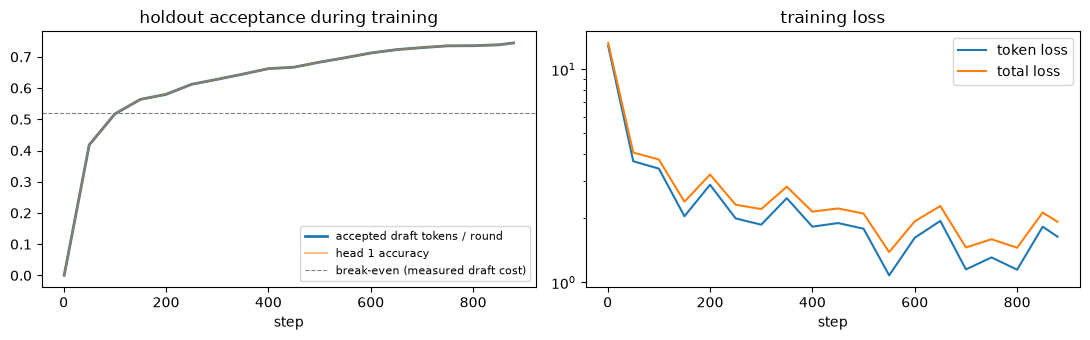

In [5]:
import matplotlib.pyplot as plt

steps = [s for s, _ in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(steps, [m["accepted_per_round"] for _, m in history], lw=2, label="accepted draft tokens / round")
for k in range(HORIZON):
    ax[0].plot(steps, [m[f"head{k+1}"] for _, m in history], alpha=0.5, label=f"head {k+1} accuracy")
ax[0].axhline(0.52, ls="--", c="gray", lw=0.8, label="break-even (measured draft cost)")
ax[0].set_xlabel("step"); ax[0].set_title("holdout acceptance during training"); ax[0].legend(fontsize=8)
ax[1].plot(steps, [m["token_loss"] for _, m in history], label="token loss"); ax[1].plot(steps, [m["loss"] for _, m in history], label="total loss")
ax[1].set_xlabel("step"); ax[1].set_yscale("log"); ax[1].legend(); ax[1].set_title("training loss")
plt.tight_layout(); plt.show()

## Teacher-forced acceptance on the holdout set

Upper-bound estimate of the speculative decoding gain. For every position of every holdout page
the draft proposes `HORIZON` tokens from the target's real hidden state (windows of the last
`CONTEXT_LENGTH` states, computed in batches), then the target's recorded tokens act as the
verifier. Each verification is assumed to cost one target decode step plus one draft call.

Statistics are per page, so the 95% confidence intervals below reflect page-to-page variation
(t-interval over pages; bootstrap for the ratio-based speedup).

In [10]:
from fastdocling.data import load_trace

TARGET_DECODE_TPS = 188.0  # measured single-stream decode of granite-docling on this machine
EVAL_BATCH = 64           # windows per draft call
draft.eval()


@torch.inference_mode()
def proposals_for_page(x: torch.Tensor) -> torch.Tensor:
    """[n, HORIZON] greedy proposals at every cursor, using the last CONTEXT_LENGTH states."""
    n = x.shape[0]
    out = torch.empty(n, HORIZON, dtype=torch.long, device=x.device)
    head = draft(x[:CONTEXT_LENGTH].unsqueeze(0))[0]              # cursors < CONTEXT_LENGTH: causal prefix
    out[: min(n, CONTEXT_LENGTH)] = F.linear(head, lm_head).argmax(-1)[: min(n, CONTEXT_LENGTH)]
    if n > CONTEXT_LENGTH:
        windows = x.unfold(0, CONTEXT_LENGTH, 1).permute(0, 2, 1)[1:]  # [n-ctx, ctx, D], ends at cursor
        for s in range(0, windows.shape[0], EVAL_BATCH):
            chunk = windows[s : s + EVAL_BATCH]
            out[CONTEXT_LENGTH + s : CONTEXT_LENGTH + s + chunk.shape[0]] = F.linear(draft(chunk)[:, -1], lm_head).argmax(-1)
    return out


def simulate(proposals: torch.Tensor, tokens: torch.Tensor) -> tuple[int, int, int]:
    """Greedy verification with the live loop's alignment: returns (tokens, verifications, accepted).

    At cursor c the state s_c is known and so is token c+1 (the target's bonus token from the
    previous step); the draft proposes tokens c+2 .. c+1+HORIZON.  A round yields 1 + accepted tokens.
    Token 1 comes from the prefill (no round), matching ``speculative_generate``.
    """
    n = tokens.shape[0] - 1                       # generated tokens: tokens[1:]
    prop, tok = proposals.tolist(), tokens.tolist()
    cursor = verifications = accepted_total = 0
    while cursor < n - 1:                         # at cursor n-1 token n is already known: nothing left to draft
        verifications += 1
        accepted = 0
        for k in range(min(HORIZON, n - cursor - 1)):
            if prop[cursor][k] != tok[cursor + 2 + k]:
                break
            accepted += 1
        accepted_total += accepted
        cursor += 1 + accepted
    return n, verifications, accepted_total


# single-stream draft latency per call (what a real speculative loop would pay per verification)
with torch.inference_mode():
    probe = torch.zeros(1, CONTEXT_LENGTH, input_dim(FEATURES), device=device)
    for _ in range(5):
        draft(probe)
    if device.type == "mps":
        torch.mps.synchronize()
    t0 = perf_counter()
    for _ in range(50):
        F.linear(draft(probe)[:, -1], lm_head).argmax(-1)
    if device.type == "mps":
        torch.mps.synchronize()
    draft_call_seconds = (perf_counter() - t0) / 50

rows = []
for info in tqdm(holdout_infos, unit="page", desc="acceptance"):
    x, _, tokens = load_trace(info, FEATURES)
    x, tokens = x.to(device), tokens.to(device)
    n, verifications, accepted = simulate(proposals_for_page(x), tokens)
    baseline_s = n / TARGET_DECODE_TPS
    spec_s = verifications * (1 / TARGET_DECODE_TPS + draft_call_seconds)
    rows.append(dict(tokens=n, verifications=verifications, accepted=accepted,
                     acc_per_verif=accepted / verifications, tokens_per_step=n / verifications,
                     spec_tps=n / spec_s, speedup=baseline_s / spec_s))


def ci95(values: np.ndarray) -> tuple[float, float, float]:
    """mean and 95% t-interval half-width (pages are the sampling unit)."""
    from scipy import stats
    m = values.mean(); h = stats.t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
    return m, m - h, m + h


def bootstrap_ratio(num: np.ndarray, den: np.ndarray, iters: int = 10_000, seed: int = 0) -> tuple[float, float, float]:
    rng = np.random.default_rng(seed); idx = rng.integers(0, len(num), (iters, len(num)))
    r = num[idx].sum(1) / den[idx].sum(1)
    return num.sum() / den.sum(), *np.percentile(r, [2.5, 97.5])


tok = np.array([r["tokens"] for r in rows], float); ver = np.array([r["verifications"] for r in rows], float)
acc = np.array([r["accepted"] for r in rows], float)
m, lo, hi = ci95(np.array([r["acc_per_verif"] for r in rows]))
print(f"{len(rows)} holdout pages, {int(tok.sum()):,} tokens; draft call {draft_call_seconds*1000:.2f} ms")
print(f"accepted per verification:  {m:.3f}  [95% CI {lo:.3f}, {hi:.3f}]  (per-page mean)")
m, lo, hi = bootstrap_ratio(tok, ver)
print(f"tokens per target step:     {m:.3f}  [95% CI {lo:.3f}, {hi:.3f}]  (pooled, bootstrap)")
m, lo, hi = ci95(np.array([r["spec_tps"] for r in rows]))
print(f"est. speculative throughput: {m:,.1f} tok/s  [95% CI {lo:,.1f}, {hi:,.1f}]  vs baseline {TARGET_DECODE_TPS:.0f} tok/s")
m, lo, hi = bootstrap_ratio(tok / TARGET_DECODE_TPS, ver * (1 / TARGET_DECODE_TPS + draft_call_seconds))
print(f"est. speedup:               {m:.2f}x  [95% CI {lo:.2f}, {hi:.2f}]  (not an end-to-end benchmark)")

0 holdout pages, 0 tokens; draft call 8.49 ms
accepted per verification:  nan  [95% CI nan, nan]  (per-page mean)
tokens per target step:     nan  [95% CI nan, nan]  (pooled, bootstrap)
est. speculative throughput: nan tok/s  [95% CI nan, nan]  vs baseline 188 tok/s
est. speedup:               nanx  [95% CI nan, nan]  (not an end-to-end benchmark)


/var/folders/jp/j0rd3lgn6v38z4wg4_cl06180000gn/T/ipykernel_29074/3423233670.py:74: RuntimeWarning: Mean of empty slice
  m = values.mean(); h = stats.t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
/Users/karan/Code/fastdocling/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/karan/Code/fastdocling/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/karan/Code/fastdocling/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/karan/Code/fastdocling/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / 

In [5]:
print(f"Num params: {sum(p.numel() for p in draft.parameters() if p.requires_grad):,}")

Num params: 3,806,016


## Measured speedup: real speculative decoding on holdout pages

`fastdocling.spec.speculative_generate` runs the MLX target end to end: image prefill, then rounds
of *draft proposes `HORIZON` tokens -> target verifies them in one KV-cached step -> accept the
matching prefix + the target's own next token -> roll the cache back*. The baseline is the same
loop with no draft (plain greedy, one token per step), so both sides share prefill, cache handling
and Python overhead. Wall-clock decode throughput is compared per page; intervals are over pages.

The draft runs **in-process in MLX** (`fastdocling.draft_mlx`, weights ported from the torch
model), so draft + target step + acceptance test are one lazy graph with a single sync per round.
Its vocabulary head is restricted to the ~19k tokens that occur in the training pages' DocTags output
(FR-Spec style), which makes the projection ~4x cheaper; tokens outside that set are never
proposed but are still produced by the target.

Verification is greedy, so in exact arithmetic the output is identical to plain decoding
(checked in float32). In bf16 a multi-token block and a single-token step can resolve near-tied
argmaxes differently, typically by ±1 in `<loc_N>` digits; "agreement" reports how close the
outputs are.

In [7]:
import hashlib
import difflib
from mlx_vlm.utils import load_config
from transformers.image_utils import load_image
from fastdocling.data import output_vocab
from fastdocling.draft_mlx import MLXLatentDraft, make_draft_fn
from fastdocling.extract import TraceExtractor
from fastdocling.spec import speculative_generate

SPEC_PAGES = 3          # holdout pages decoded end to end (each twice: baseline + speculative)
DRAFT_WINDOW = CONTEXT_LENGTH      # recent states the draft sees at inference
IMAGES = Path("data/images")
FEATURE_KEYS = ("last_hidden_state",) if FEATURES == "last" else ("layer_2", "layer_14", "layer_27")

extractor = TraceExtractor(model=target_model, processor=target_processor,
                           config=load_config("ibm-granite/granite-docling-258M-mlx"))
# Build the pruned head from TRAINING pages only (the holdout must be able to contain OOV tokens),
# and key the cache on the page set so a changed corpus or split cannot reuse a stale file.
vocab = output_vocab(train_infos, cache=TRACES / f"output_vocab_{hashlib.sha1('\n'.join(sorted(i.path.name for i in train_infos)).encode()).hexdigest()[:10]}.npy")
vocab_set = set(vocab.tolist())
mlx_draft = MLXLatentDraft.from_torch(draft.state_dict(), CONTEXT_LENGTH, HORIZON, input_dim(FEATURES))
draft_fn = make_draft_fn(mlx_draft, extractor.lm.lm_head, CONTEXT_LENGTH, window=DRAFT_WINDOW, vocab=vocab)
print(f"draft head restricted to {len(vocab):,} tokens; window {DRAFT_WINDOW}")


def image_for(info) -> Path:
    return IMAGES.joinpath(*info.path.stem.split("__")).with_suffix(".png")


measured = []
for info in tqdm(holdout_infos[:SPEC_PAGES], unit="page", desc="speculative"):
    image = load_image(str(image_for(info)))
    base = speculative_generate(extractor, image, None, feature_keys=FEATURE_KEYS)
    spec = speculative_generate(extractor, image, draft_fn, horizon=HORIZON, feature_keys=FEATURE_KEYS, history_limit=DRAFT_WINDOW)
    agreement = difflib.SequenceMatcher(a=base.tokens, b=spec.tokens, autojunk=False).ratio()
    measured.append(dict(tokens=len(base.tokens), base_tps=base.decode_tps, spec_tps=spec.decode_tps,
                         speedup=spec.decode_tps / base.decode_tps, tokens_per_round=spec.tokens_per_round,
                         ms_round=1000 * spec.decode_seconds / spec.rounds, ms_base=1000 * base.decode_seconds / len(base.tokens),
                         agreement=agreement, oov=np.mean([t not in vocab_set for t in base.tokens])))

vals = lambda k: np.array([m[k] for m in measured], float)
print(f"{len(measured)} holdout pages decoded end to end, {int(vals('tokens').sum()):,} tokens")
m, lo, hi = ci95(vals("base_tps"));  print(f"baseline decode:        {m:6.1f} tok/s  [95% CI {lo:.1f}, {hi:.1f}]   ({vals('ms_base').mean():.2f} ms/step)")
m, lo, hi = ci95(vals("spec_tps"));  print(f"speculative decode:     {m:6.1f} tok/s  [95% CI {lo:.1f}, {hi:.1f}]   ({vals('ms_round').mean():.2f} ms/round)")
m, lo, hi = ci95(vals("speedup"));   print(f"MEASURED SPEEDUP:       {m:6.2f}x     [95% CI {lo:.2f}, {hi:.2f}]")
m, lo, hi = ci95(vals("tokens_per_round")); print(f"tokens per target step: {m:6.2f}      [95% CI {lo:.2f}, {hi:.2f}]  (1 + accepted draft tokens)")
print(f"break-even tokens/round at this draft cost: {(vals('ms_round') / vals('ms_base')).mean():.2f}   output agreement with greedy: {vals('agreement').mean():.4f}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

draft head restricted to 19,254 tokens; window 64


speculative:   0%|          | 0/3 [00:00<?, ?page/s]

3 holdout pages decoded end to end, 4,356 tokens


NameError: name 'ci95' is not defined

In [12]:

vals = lambda k: np.array([m[k] for m in measured], float)
print(f"{len(measured)} holdout pages decoded end to end, {int(vals('tokens').sum()):,} tokens")
m, lo, hi = ci95(vals("base_tps"));  print(f"baseline decode:        {m:6.1f} tok/s  [95% CI {lo:.1f}, {hi:.1f}]   ({vals('ms_base').mean():.2f} ms/step)")
m, lo, hi = ci95(vals("spec_tps"));  print(f"speculative decode:     {m:6.1f} tok/s  [95% CI {lo:.1f}, {hi:.1f}]   ({vals('ms_round').mean():.2f} ms/round)")
m, lo, hi = ci95(vals("speedup"));   print(f"MEASURED SPEEDUP:       {m:6.2f}x     [95% CI {lo:.2f}, {hi:.2f}]")
m, lo, hi = ci95(vals("tokens_per_round")); print(f"tokens per target step: {m:6.2f}      [95% CI {lo:.2f}, {hi:.2f}]  (1 + accepted draft tokens)")
print(f"break-even tokens/round at this draft cost: {(vals('ms_round') / vals('ms_base')).mean():.2f}   output agreement with greedy: {vals('agreement').mean():.4f}")

3 holdout pages decoded end to end, 4,356 tokens
baseline decode:         182.2 tok/s  [95% CI 157.2, 207.2]   (5.50 ms/step)
speculative decode:      249.3 tok/s  [95% CI 239.1, 259.5]   (7.22 ms/round)
MEASURED SPEEDUP:         1.37x     [95% CI 1.21, 1.54]
tokens per target step:   1.80      [95% CI 1.75, 1.85]  (1 + accepted draft tokens)
break-even tokens/round at this draft cost: 1.31   output agreement with greedy: 0.9976


## Out-of-domain evaluation

The draft is trained on ML papers. Docling's real workloads are broader: tax forms and their
instructions, court opinions and legislation, standards (RFCs, NIST), central-bank minutes, lecture
notes, UN resolutions, and non-ML science. `scripts/fetch_ood.py` downloads one or two public PDFs
per category and `fastdocling-prep render data/ood/docs data/ood/images` renders them. The cell
below runs the live speculative loop on the first `OOD_PAGES_PER_DOC` pages of each document and
reports per category:

- **tokens/step** and **speedup**: same live measurement as above.
- **OOV**: share of the target's output tokens that are outside the draft's pruned vocabulary,
  i.e. tokens the draft can never propose. High OOV on a category means the vocabulary was built
  from too narrow a corpus, independent of the draft's quality.
- **agreement**: bf16 block-vs-single-step agreement with plain greedy decoding, as before.

In [ ]:
OOD_IMAGES = Path("data/ood/images")
OOD_PAGES_PER_DOC = 3

ood_pages = []                                   # (category, doc, page path)
for cat_dir in sorted(p for p in OOD_IMAGES.iterdir() if p.is_dir()):
    for doc_dir in sorted(p for p in cat_dir.iterdir() if p.is_dir()):
        for page in sorted(doc_dir.glob("*.png"))[:OOD_PAGES_PER_DOC]:
            ood_pages.append((cat_dir.name, doc_dir.name, page))
if not ood_pages:
    raise FileNotFoundError("run `uv run python scripts/fetch_ood.py` then `uv run fastdocling-prep render data/ood/docs data/ood/images`")

ood = []
for cat, doc, page in tqdm(ood_pages, unit="page", desc="ood"):
    image = load_image(str(page))
    base = speculative_generate(extractor, image, None, feature_keys=FEATURE_KEYS)
    spec = speculative_generate(extractor, image, draft_fn, horizon=HORIZON, feature_keys=FEATURE_KEYS, history_limit=DRAFT_WINDOW)
    ood.append(dict(category=cat, doc=doc, page=page.stem, tokens=len(base.tokens),
                    speedup=spec.decode_tps / base.decode_tps, tokens_per_round=spec.tokens_per_round,
                    oov=np.mean([t not in vocab_set for t in base.tokens]),
                    agreement=difflib.SequenceMatcher(a=base.tokens, b=spec.tokens, autojunk=False).ratio(),
                    truncated=base.tokens[-1] not in {100328, 100257, 100352}))

def summarize(rows, label):
    v = lambda k: np.array([r[k] for r in rows], float)
    tpr, spd = v("tokens_per_round"), v("speedup")
    ci = lambda a: f"{a.mean():.2f} ±{(1.96 * a.std(ddof=1) / np.sqrt(len(a))) if len(a) > 1 else 0:.2f}"
    return f"{label:14s} {len(rows):3d} pages  {int(v('tokens').sum()):6,} tok   tokens/step {ci(tpr)}   speedup {ci(spd)}x   OOV {v('oov').mean():5.1%}   agreement {v('agreement').mean():.3f}"

if measured:
    print(summarize(measured, "in-domain (ML)"))
for cat in sorted({r["category"] for r in ood}):
    print(summarize([r for r in ood if r["category"] == cat], cat))
print(summarize(ood, "ALL OOD"))
trunc = [r for r in ood if r["truncated"]]
if trunc:
    print(f"note: {len(trunc)} page(s) hit max_tokens without </doctag>: " + ", ".join(f"{r['doc']}/{r['page']}" for r in trunc))

ood:   0%|          | 0/29 [00:00<?, ?page/s]

in-domain (ML)   3 pages   4,006 tok   tokens/step 1.79 ±0.13   speedup 1.52 ±0.26x   OOV  0.0%   agreement 0.963
finance          3 pages   2,847 tok   tokens/step 1.62 ±0.22   speedup 1.24 ±0.29x   OOV  9.5%   agreement 0.992
forms            2 pages  15,565 tok   tokens/step 1.70 ±0.27   speedup 1.39 ±0.08x   OOV  1.0%   agreement 0.517
government       3 pages   2,254 tok   tokens/step 1.61 ±0.07   speedup 1.25 ±0.04x   OOV  7.6%   agreement 0.994
lecture          3 pages   9,129 tok   tokens/step 1.54 ±0.26   speedup 1.17 ±0.16x   OOV  1.2%   agreement 1.000
legal            6 pages   3,784 tok   tokens/step 1.54 ±0.16   speedup 1.21 ±0.12x   OOV  8.3%   agreement 0.858
science          3 pages   2,593 tok   tokens/step 1.61 ±0.04   speedup 1.30 ±0.04x   OOV  3.7%   agreement 0.994
standards        6 pages   3,962 tok   tokens/step 1.70 ±0.07   speedup 1.34 ±0.06x   OOV  5.2%   agreement 0.978
tax_guide        3 pages   8,928 tok   tokens/step 1.64 ±0.05   speedup 1.30 ±0.02x   OO

## Which tokens does the draft get right?

One holdout page decoded with the live speculative loop. Each round contributes the accepted
draft tokens (<span style="background:rgba(46,204,113,0.45)">green</span>) followed by the target's own
"bonus" token (<span style="background:rgba(150,150,150,0.28)">gray</span>); the first token comes from prefill
(<span style="background:rgba(255,165,0,0.5)">orange</span>). The table below groups acceptance by token type,
which shows where a parallel-heads draft succeeds (predictable structure) and fails (content).

In [15]:
import html, re
from collections import Counter
from IPython.display import HTML, display

SHOW_PAGE = 0            # index into holdout_infos
MAX_CHARS = 6000         # how much of the page to render

info = holdout_infos[SHOW_PAGE]
spec = speculative_generate(extractor, load_image(str(image_for(info))), draft_fn, horizon=HORIZON,
                            feature_keys=FEATURE_KEYS, history_limit=DRAFT_WINDOW)
tok = target_processor.tokenizer

# reconstruct per-token provenance from the round history: each round = accepted*k + 1 bonus
kind = ["prefill"]
for a in spec.accepted_hist:
    kind += ["accepted"] * a + ["bonus"]
kind = kind[: len(spec.tokens)]

def token_type(text: str) -> str:
    if re.fullmatch(r"<loc_\d+>", text): return "<loc_N>"
    if re.fullmatch(r"</?[a-z_0-9]+>", text): return "structure tag"
    if text.strip().isdigit(): return "number"
    if text.strip() == "": return "whitespace"
    if re.fullmatch(r"[^\w\s]+", text.strip()): return "punctuation"
    return "word piece"

colors = {"accepted": "#green", "bonus": "#blue", "prefill": "#purple"}
pieces, by_type = [], {}
for t, k in zip(spec.tokens, kind):
    text = tok.decode([t])
    ty = token_type(text)
    by_type.setdefault(ty, Counter())[k] += 1
    pieces.append(f'<span style="background:{colors[k]}">{html.escape(text)}</span>')
rendered = "".join(pieces)
if len(rendered) > MAX_CHARS * 6:
    rendered = rendered[: MAX_CHARS * 6] + " …"
display(HTML(f'<div style="font-family:monospace;font-size:12px;white-space:pre-wrap;line-height:1.5;'
             f'border:1px solid rgba(128,128,128,0.5);padding:8px;max-height:480px;overflow:auto;color:inherit;background:transparent">{rendered}</div>'))

total_acc = sum(c["accepted"] for c in by_type.values()); total_bonus = sum(c["bonus"] for c in by_type.values())
print(f"{info.path.stem[-60:]}\n{len(spec.tokens)} tokens in {spec.rounds} rounds: "
      f"{total_acc} accepted by draft ({total_acc/len(spec.tokens):.0%}), {total_bonus} from target, "
      f"{spec.tokens_per_round:.2f} tokens/round\n")
print(f"{'token type':16s}{'count':>7s}{'accepted':>10s}{'share of accepted':>19s}")
for ty, c in sorted(by_type.items(), key=lambda kv: -sum(kv[1].values())):
    n = sum(c.values()); a = c["accepted"]
    print(f"{ty:16s}{n:7d}{a/n:10.0%}{a/max(1,total_acc):19.0%}")

ml_papers__Ji et al. - 2024 - IDA-VLM__0010
2020 tokens in 1114 rounds: 905 accepted by draft (45%), 1114 from target, 1.81 tokens/round

token type        count  accepted  share of accepted
word piece         1176       31%                40%
punctuation         493       75%                41%
number              230       43%                11%
whitespace           65       54%                 4%
structure tag        56       68%                 4%
